# VeriTriage — Model Training
## Notebook 03: XGBoost Multi-Task Verification Triage

**Author:** Tushar Dudeja  
**Project:** VeriTriage — ML-Based Sign-Off Verification Triage  

---

### Objective
Train XGBoost classifiers to predict sign-off verification failures
from placement-stage features — before running expensive EDA tools.

### Three Tasks
| Task | Input | Output | Threshold |
|------|-------|--------|-----------|
| IR Drop | Cell density + Macro region | FAIL if max IR > 5.0 mV | 5.0 mV |
| DRC | Cell density + Macro region | FAIL if violations > 1500 | 1500 count |
| Congestion | Cell density + Macro region | FAIL if overflow > 3.0 | 3.0 |

### Train / Val / Test Split
- 70% training — 15% validation — 15% test
- Stratified split to preserve class balance

## 1. Imports and Configuration

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from pathlib import Path

ROOT = Path(r"C:\Users\TUSHAR\2026-27\PROJECTS\VeriTriage")
(ROOT / "models").mkdir(parents=True, exist_ok=True)
(ROOT / "results/plots").mkdir(parents=True, exist_ok=True)

print(f"XGBoost version: {xgb.__version__}")
print(f"Project root:    {ROOT}")

XGBoost version: 1.7.6
Project root:    C:\Users\TUSHAR\2026-27\PROJECTS\VeriTriage


## 2. Load Feature Dataset

In [8]:
df = pd.read_csv(ROOT / "data/processed/veritriage_features.csv")

FEATURE_COLS = [c for c in df.columns if c.startswith('cd_') or c.startswith('mr_')]
LABEL_COLS   = ['label_ir', 'label_drc', 'label_cg']
TASK_NAMES   = ['IR Drop', 'DRC', 'Congestion']

X = df[FEATURE_COLS].values

print(f"Dataset shape:   {df.shape}")
print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"Labels:          {LABEL_COLS}")
print(f"\nLabel distribution:")
for col, name in zip(LABEL_COLS, TASK_NAMES):
    fail = df[col].sum()
    pass_ = len(df) - fail
    print(f"  {name:12s} → FAIL: {fail:5d} ({fail/len(df)*100:.1f}%) | PASS: {pass_:5d} ({pass_/len(df)*100:.1f}%)")

Dataset shape:   (10242, 53)
Feature columns: 42
Labels:          ['label_ir', 'label_drc', 'label_cg']

Label distribution:
  IR Drop      → FAIL:  4507 (44.0%) | PASS:  5735 (56.0%)
  DRC          → FAIL:  5140 (50.2%) | PASS:  5102 (49.8%)
  Congestion   → FAIL:  5044 (49.2%) | PASS:  5198 (50.8%)


## 3. Train XGBoost Models — One Per Task

In [9]:
models  = {}
results = {}
splits  = {}

for label, task in zip(LABEL_COLS, TASK_NAMES):
    print(f"\n{'='*55}")
    print(f"  Training: {task}")
    print(f"{'='*55}")

    y = df[label].values

    # Stratified 70/15/15 split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

    splits[label] = (X_test, y_test)
    print(f"  Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

    # Train
    clf = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
    clf.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False)

    # Evaluate
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[task] = {'Accuracy': round(acc,4), 'F1': round(f1,4), 'ROC-AUC': round(auc,4)}
    models[label] = clf

    print(f"\n  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC-AUC:  {auc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['PASS','FAIL'])}")

    # Save model
    joblib.dump(clf, ROOT / f"models/{label}_xgb.pkl")
    print(f"  Saved: models/{label}_xgb.pkl")


  Training: IR Drop
  Train: 7169 | Val: 1536 | Test: 1537

  Accuracy: 0.8510 (85.10%)
  F1 Score: 0.8210
  ROC-AUC:  0.9243

              precision    recall  f1-score   support

        PASS       0.84      0.91      0.87       861
        FAIL       0.87      0.78      0.82       676

    accuracy                           0.85      1537
   macro avg       0.85      0.84      0.85      1537
weighted avg       0.85      0.85      0.85      1537

  Saved: models/label_ir_xgb.pkl

  Training: DRC
  Train: 7169 | Val: 1536 | Test: 1537

  Accuracy: 0.8321 (83.21%)
  F1 Score: 0.8264
  ROC-AUC:  0.9149

              precision    recall  f1-score   support

        PASS       0.81      0.87      0.84       766
        FAIL       0.86      0.80      0.83       771

    accuracy                           0.83      1537
   macro avg       0.83      0.83      0.83      1537
weighted avg       0.83      0.83      0.83      1537

  Saved: models/label_drc_xgb.pkl

  Training: Congestion
  T

## 4. Results Summary Table

In [11]:
df_results = pd.DataFrame(results).T
print("="*45)
print("  VERITRIAGE — FINAL RESULTS SUMMARY")
print("="*45)
print(df_results.to_string())
df_results.to_csv(ROOT / "data/processed/model_results.csv")
print("\nSaved to data/processed/model_results.csv")

  VERITRIAGE — FINAL RESULTS SUMMARY
            Accuracy      F1  ROC-AUC
IR Drop       0.8510  0.8210   0.9243
DRC           0.8321  0.8264   0.9149
Congestion    0.9323  0.9293   0.9617

Saved to data/processed/model_results.csv


## 5. Accuracy and AUC Bar Charts

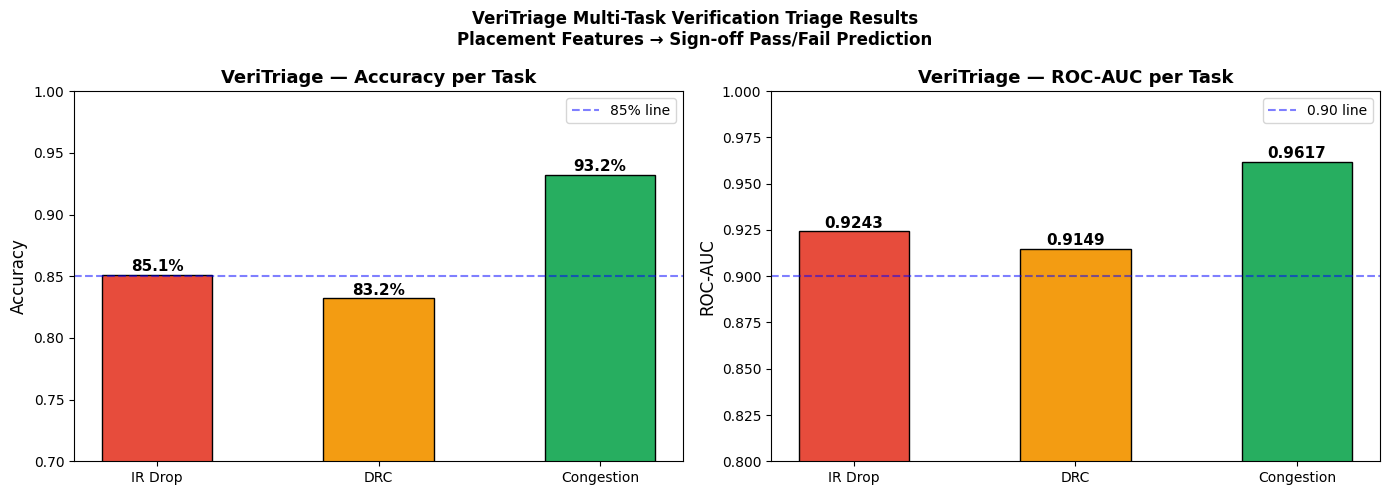

Saved: results/plots/03_model_results.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tasks  = list(results.keys())
accs   = [results[t]['Accuracy'] for t in tasks]
aucs   = [results[t]['ROC-AUC']  for t in tasks]
colors = ['#e74c3c', '#f39c12', '#27ae60']

# Accuracy
bars1 = axes[0].bar(tasks, accs, color=colors, edgecolor='black', width=0.5)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('VeriTriage — Accuracy per Task', fontsize=13, fontweight='bold')
axes[0].axhline(0.85, color='blue', linestyle='--', alpha=0.5, label='85% line')
axes[0].legend()
for bar, val in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=11)

# AUC
bars2 = axes[1].bar(tasks, aucs, color=colors, edgecolor='black', width=0.5)
axes[1].set_ylim(0.8, 1.0)
axes[1].set_ylabel('ROC-AUC', fontsize=12)
axes[1].set_title('VeriTriage — ROC-AUC per Task', fontsize=13, fontweight='bold')
axes[1].axhline(0.90, color='blue', linestyle='--', alpha=0.5, label='0.90 line')
axes[1].legend()
for bar, val in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('VeriTriage Multi-Task Verification Triage Results\n'
             'Placement Features → Sign-off Pass/Fail Prediction',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / "results/plots/03_model_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/plots/03_model_results.png")

## 6. Confusion Matrices

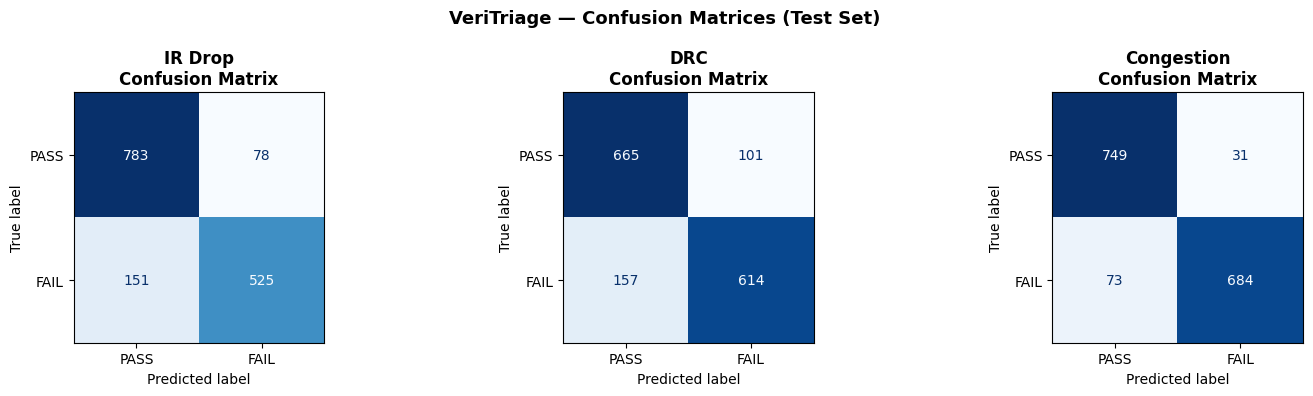

Saved: results/plots/03_confusion_matrices.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (label, task) in enumerate(zip(LABEL_COLS, TASK_NAMES)):
    X_test, y_test = splits[label]
    y_pred = models[label].predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['PASS', 'FAIL'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{task}\nConfusion Matrix', 
                        fontsize=12, fontweight='bold')

plt.suptitle('VeriTriage — Confusion Matrices (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / "results/plots/03_confusion_matrices.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/plots/03_confusion_matrices.png")